# 03 Normalfordeling
Data Mining & Analytics – Samling 2, dag 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42) 

## Normalfordelingen

Kroppshøyde hos voksne menn i Norge: ca. $N(\mu = 181, \sigma = 7)$ cm (illustrasjon).

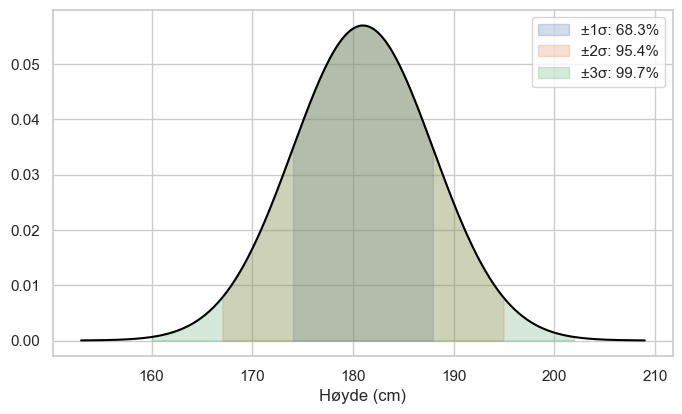

In [2]:
mu_h, sd_h = 181, 7
h = stats.norm(mu_h, sd_h)


x = np.linspace(mu_h - 4 * sd_h, mu_h + 4 * sd_h, 400)
y = h.pdf(x)
plt.plot(x, y, color="black")
for k_, farge in [(1, "C0"), (2, "C1"), (3, "C2")]:
    m = (x > mu_h - k_ * sd_h) & (x < mu_h + k_ * sd_h)
    plt.fill_between(x[m], h.pdf(x[m]), alpha=0.25, color=farge, label=f"±{k_}σ: {h.cdf(mu_h + k_*sd_h) - h.cdf(mu_h - k_*sd_h):.1%}")
plt.legend()
plt.xlabel("Høyde (cm)")
plt.show()

## Er dataene normalfordelte?

Mange metoder antar (tilnærmet) normalitet. Sjekk med Shapiro–Wilk.
(Shapiro–Wilk: H₀ = «dataene er normalfordelte» - p>0.05) og evt et QQ-plott

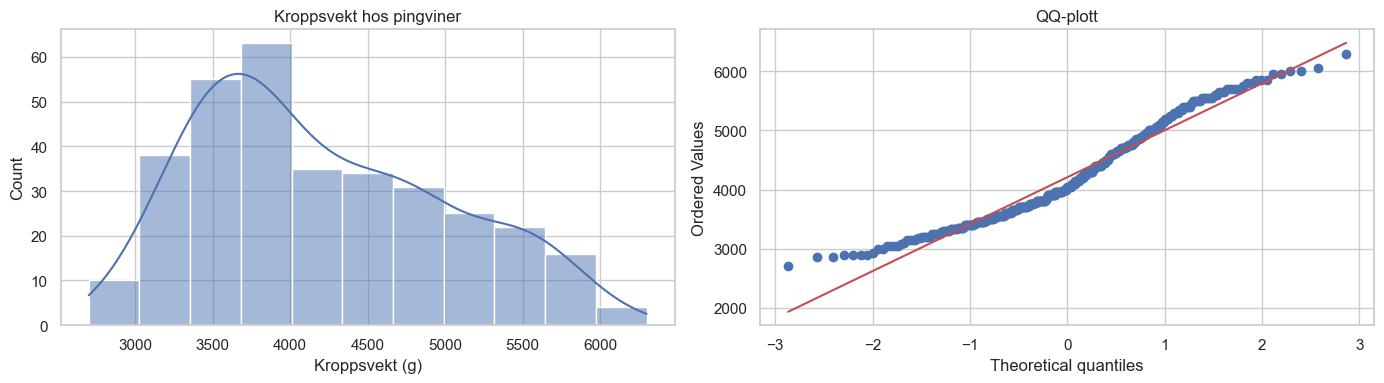

Shapiro:  p = 3.567711408268874e-08


In [3]:
pingvin = pd.read_csv("../Data/penguins.csv").dropna()


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(pingvin["body_mass_g"], kde=True, ax=ax[0])
ax[0].set_title("Kroppsvekt hos pingviner") 
ax[0].set_xlabel("Kroppsvekt (g)")


stats.probplot(pingvin["body_mass_g"], dist="norm", plot=ax[1])
ax[1].set_title("QQ-plott")

plt.tight_layout()
plt.show()

print("Shapiro:  p =", stats.shapiro(pingvin["body_mass_g"]).pvalue)

Skjeve, positive data (inntekt, ventetid, priser) blir ofte mer symmetriske etter **log-transformasjon**:

Shapiro inntekt:      p = 1.14e-40
Shapiro log(inntekt): p = 0.6007091622509394


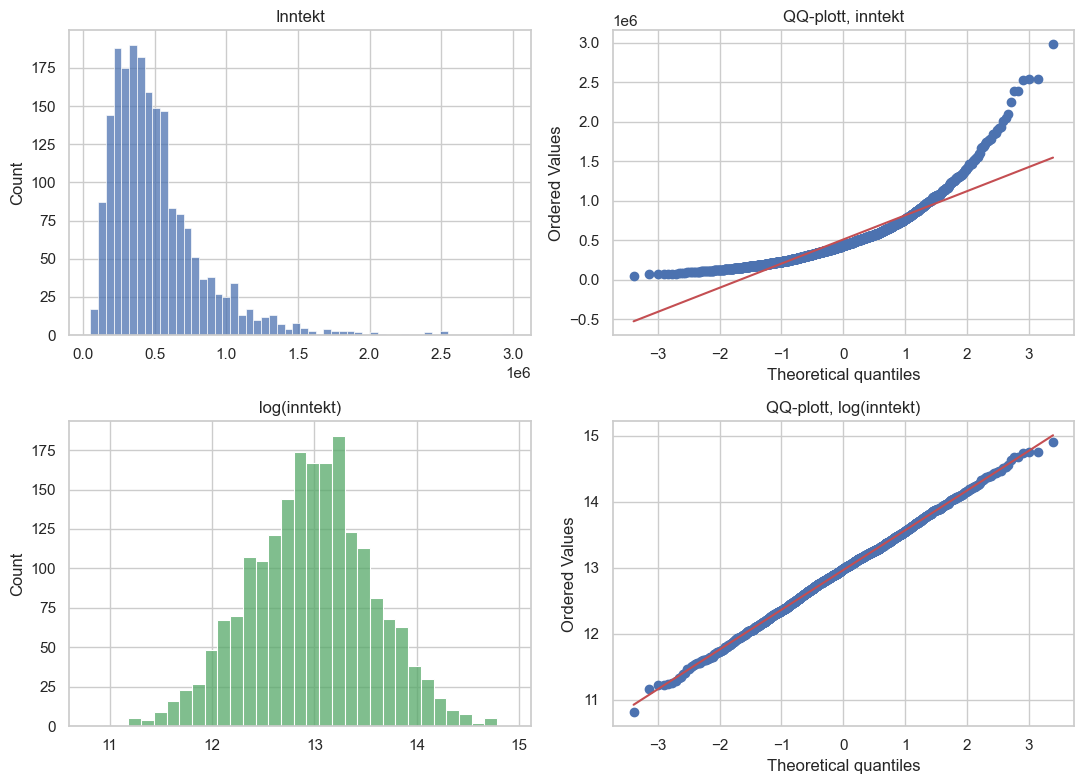

In [4]:
inntekt = rng.lognormal(mean=13, sigma=0.6, size=2000)
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(inntekt, ax=ax[0, 0])
ax[0, 0].set_title(f"Inntekt")
stats.probplot(inntekt, dist="norm", plot=ax[0, 1])
ax[0, 1].set_title("QQ-plott, inntekt")

sns.histplot(np.log(inntekt), ax=ax[1, 0], color="C2")
ax[1, 0].set_title(f"log(inntekt)")
stats.probplot(np.log(inntekt), dist="norm", plot=ax[1, 1])
ax[1, 1].set_title("QQ-plott, log(inntekt)")

plt.tight_layout()
print("Shapiro inntekt:      p =", f"{stats.shapiro(inntekt).pvalue:.2e}")
print("Shapiro log(inntekt): p =", f"{stats.shapiro(np.log(inntekt)).pvalue}")
plt.show()
